In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

import os
os.chdir("/content/drive/MyDrive/shrey/")

In [3]:
!pip install pandas matplotlib seaborn numpy


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load the complete dataset
df_raw = pd.read_excel('cleaned data.xlsx', header=None)

# Extract dates
dates = df_raw.iloc[3:, 0].copy()
dates = pd.to_datetime(dates, errors='coerce').dropna()

# Column mapping based on discovered structure
data_columns = {
    'DAL': 1, 'AAL': 3, 'RYA': 5, 'LHA': 8, 'SIA': 11, 'QAN': 14, 'IAG': 17,
    'CO1_Brent': 21, 'CL1': 22, 'WT1': 23,
    'EURUSD': 26, 'GBPUSD': 27, 'AUDUSD': 28, 'SGDUSD': 29
}

# Create comprehensive DataFrame
data = {'Date': dates}
for name, col_idx in data_columns.items():
    if col_idx < df_raw.shape[1]:
        values = df_raw.iloc[3:len(dates)+3, col_idx].copy()
        data[name] = pd.to_numeric(values, errors='coerce')

df = pd.DataFrame(data)

# Create airline indices with consistent methodology
us_airlines = ['DAL', 'AAL']
eu_airlines = ['LHA', 'IAG', 'RYA']
asia_airlines = ['SIA', 'QAN']
all_airlines = us_airlines + eu_airlines + asia_airlines

# Calculate indices (equal weighted)
df['US_Airline_Index'] = df[us_airlines].mean(axis=1)
df['EU_Airline_Index'] = df[eu_airlines].mean(axis=1)
df['Asia_Airline_Index'] = df[asia_airlines].mean(axis=1)
df['Global_Airline_Index'] = df[all_airlines].mean(axis=1)
df['Non_US_Airline_Index'] = df[eu_airlines + asia_airlines].mean(axis=1)

# Normalize all indices to 100 at first valid observation
indices = ['US_Airline_Index', 'EU_Airline_Index', 'Asia_Airline_Index',
          'Global_Airline_Index', 'Non_US_Airline_Index']

for idx in indices:
    first_valid = df[idx].first_valid_index()
    if first_valid is not None:
        df[f'{idx}_Norm'] = (df[idx] / df[idx].loc[first_valid]) * 100

# Key event dates
covid_start = pd.to_datetime('2020-03-11')  # WHO declares pandemic
covid_end = pd.to_datetime('2022-05-05')    # End of COVID emergency
ukraine_invasion = pd.to_datetime('2022-02-24')
opec_cut = pd.to_datetime('2022-10-05')
pandemic_start = pd.to_datetime('2020-03-01')  # For pre/post analysis

print("Dataset loaded successfully!")
print(f"Data range: {df['Date'].min()} to {df['Date'].max()}")
print(f"COVID period: {covid_start} to {covid_end}")

# Set consistent color palette and style
colors = {
    'US_Airlines': '#1f77b4',      # Blue
    'EU_Airlines': '#ff7f0e',      # Orange
    'Asia_Airlines': '#2ca02c',    # Green
    'Global_Airlines': '#d62728',  # Red
    'Oil': '#8c564b',              # Brown
    'FX': '#9467bd',               # Purple
    'Events': '#e377c2'            # Pink
}

plt.style.use('default')
sns.set_palette("husl")

def setup_plot_style():
    """Set consistent plot styling"""
    plt.rcParams.update({
        'font.size': 10,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'legend.fontsize': 10,
        'figure.titlesize': 16
    })

setup_plot_style()


Dataset loaded successfully!
Data range: 2018-01-01 00:00:00 to 2024-12-31 00:00:00
COVID period: 2020-03-11 00:00:00 to 2022-05-05 00:00:00


In [5]:
def chart_2a_airline_vs_oil_pre_post_pandemic():
    """Chart 2-A: Airline Index vs Oil, Pre vs Post Pandemic"""

    pre_pandemic = df[df['Date'] < pandemic_start].copy()
    post_pandemic = df[df['Date'] >= pandemic_start].copy()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Pre-pandemic
    if len(pre_pandemic) > 0:
        valid_pre = pre_pandemic[['CO1_Brent', 'Global_Airline_Index_Norm']].dropna()
        ax1.scatter(valid_pre['CO1_Brent'], valid_pre['Global_Airline_Index_Norm'],
                   alpha=0.7, color=colors['Global_Airlines'], s=40, label='Pre-Pandemic')

        if len(valid_pre) > 1:
            z = np.polyfit(valid_pre['CO1_Brent'], valid_pre['Global_Airline_Index_Norm'], 1)
            p = np.poly1d(z)
            ax1.plot(valid_pre['CO1_Brent'], p(valid_pre['CO1_Brent']),
                    color=colors['Oil'], linestyle='--', linewidth=2, alpha=0.8)

            # Calculate correlation
            corr = valid_pre['CO1_Brent'].corr(valid_pre['Global_Airline_Index_Norm'])
            ax1.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax1.transAxes,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    ax1.set_xlabel('Brent Oil Price ($/barrel)', fontweight='bold')
    ax1.set_ylabel('Global Airline Index (Normalized to 100)', fontweight='bold')
    ax1.set_title('Pre-Pandemic Period\n(Jan 2018 - Feb 2020)', fontweight='bold')
    ax1.grid(True, alpha=0.3)

    # Post-pandemic
    if len(post_pandemic) > 0:
        valid_post = post_pandemic[['CO1_Brent', 'Global_Airline_Index_Norm']].dropna()
        ax2.scatter(valid_post['CO1_Brent'], valid_post['Global_Airline_Index_Norm'],
                   alpha=0.7, color=colors['Events'], s=40, label='Post-Pandemic')

        if len(valid_post) > 1:
            z = np.polyfit(valid_post['CO1_Brent'], valid_post['Global_Airline_Index_Norm'], 1)
            p = np.poly1d(z)
            ax2.plot(valid_post['CO1_Brent'], p(valid_post['CO1_Brent']),
                    color=colors['Oil'], linestyle='--', linewidth=2, alpha=0.8)

            corr = valid_post['CO1_Brent'].corr(valid_post['Global_Airline_Index_Norm'])
            ax2.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax2.transAxes,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    ax2.set_xlabel('Brent Oil Price ($/barrel)', fontweight='bold')
    ax2.set_ylabel('Global Airline Index (Normalized to 100)', fontweight='bold')
    ax2.set_title('Post-Pandemic Period\n(Mar 2020 - Present)', fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Chart 2-A: Airline Index vs Oil (Pre vs Post Pandemic)',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [6]:
def chart_3a_brent_vs_eu_ukraine_war():
    """Chart 3-A: Brent vs EU Airlines, Jan-Jun 2022 with Ukraine event"""

    start_date = pd.to_datetime('2022-01-01')
    end_date = pd.to_datetime('2022-06-30')
    filtered_data = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

    if len(filtered_data) == 0:
        print("No data available for Jan-Jun 2022 period")
        return

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    # EU Airline Index
    ax1.plot(filtered_data['Date'], filtered_data['EU_Airline_Index_Norm'],
             color=colors['EU_Airlines'], linewidth=3, label='EU Airline Mini-Index')
    ax1.axvline(x=ukraine_invasion, color=colors['Events'], linestyle='--',
                linewidth=3, label='Ukraine Invasion (24 Feb 2022)')

    # Add shaded region for immediate impact
    impact_end = ukraine_invasion + pd.Timedelta(days=14)
    ax1.axvspan(ukraine_invasion, impact_end, alpha=0.2, color=colors['Events'])

    ax1.set_ylabel('EU Airline Index (Normalized)', fontweight='bold')
    ax1.set_title('Chart 3-A: Brent Oil vs EU Airline Mini-Index (Jan–Jun 2022)',
                  fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Brent Oil
    ax2.plot(filtered_data['Date'], filtered_data['CO1_Brent'],
             color=colors['Oil'], linewidth=3, label='Brent Crude Oil (CO1)')
    ax2.axvline(x=ukraine_invasion, color=colors['Events'], linestyle='--',
                linewidth=3, label='Ukraine Invasion (24 Feb 2022)')
    ax2.axvspan(ukraine_invasion, impact_end, alpha=0.2, color=colors['Events'])

    ax2.set_xlabel('Date', fontweight='bold')
    ax2.set_ylabel('Brent Oil Price ($/barrel)', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # Format x-axis
    ax2.xaxis.set_major_locator(mdates.MonthLocator())
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    plt.tight_layout()
    plt.show()

def chart_3b_brent_opec_cut():
    """Chart 3-B: Brent with OPEC+ cut event marker"""

    start_date = pd.to_datetime('2022-09-01')
    end_date = pd.to_datetime('2022-11-30')
    filtered_data = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

    if len(filtered_data) == 0:
        print("No data available for Sep-Nov 2022 period")
        return

    plt.figure(figsize=(14, 6))

    # Plot Brent oil
    plt.plot(filtered_data['Date'], filtered_data['CO1_Brent'],
             color=colors['Oil'], linewidth=3, label='Brent Crude Oil (CO1)')

    # OPEC+ event marker
    plt.axvline(x=opec_cut, color=colors['Events'], linestyle='--', linewidth=3,
                label='OPEC+ Production Cut (Oct 5, 2022)')

    # Add pre/post shading
    pre_window = opec_cut - pd.Timedelta(days=7)
    post_window = opec_cut + pd.Timedelta(days=7)
    plt.axvspan(pre_window, opec_cut, alpha=0.2, color='blue', label='Pre-Cut Period')
    plt.axvspan(opec_cut, post_window, alpha=0.2, color='red', label='Post-Cut Period')

    # Event marker
    opec_day_data = filtered_data[filtered_data['Date'].dt.date == opec_cut.date()]
    if not opec_day_data.empty:
        plt.scatter([opec_cut], [opec_day_data['CO1_Brent'].iloc[0]],
                   color=colors['Events'], s=200, marker='o', zorder=5,
                   edgecolors='black', linewidths=2)

    plt.xlabel('Date', fontweight='bold')
    plt.ylabel('Brent Oil Price ($/barrel)', fontweight='bold')
    plt.title('Chart 3-B: Brent Oil - OPEC+ Production Cut Impact (Oct 2022)',
              fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


In [7]:

def chart_4a_brent_vs_airline_2018_2023():
    """Chart 4-A: Brent vs Airline Index, 2018-2023"""

    plt.figure(figsize=(14, 8))

    # Scatter plot with time color coding
    valid_data = df[['CO1_Brent', 'Global_Airline_Index_Norm', 'Date']].dropna()
    scatter = plt.scatter(valid_data['CO1_Brent'], valid_data['Global_Airline_Index_Norm'],
                         c=valid_data['Date'].dt.year, cmap='viridis',
                         alpha=0.7, s=40, edgecolors='black', linewidths=0.5)

    # Add trend line
    if len(valid_data) > 1:
        z = np.polyfit(valid_data['CO1_Brent'], valid_data['Global_Airline_Index_Norm'], 1)
        p = np.poly1d(z)
        plt.plot(valid_data['CO1_Brent'], p(valid_data['CO1_Brent']),
                color='red', linestyle='--', linewidth=2, alpha=0.8)

        # Correlation
        corr = valid_data['CO1_Brent'].corr(valid_data['Global_Airline_Index_Norm'])
        plt.text(0.05, 0.95, f'Overall Correlation: {corr:.3f}',
                transform=plt.gca().transAxes, fontsize=12, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    plt.colorbar(scatter, label='Year')
    plt.xlabel('Brent Oil Price ($/barrel)', fontweight='bold')
    plt.ylabel('Global Airline Index (Normalized to 100)', fontweight='bold')
    plt.title('Chart 4-A: Brent Oil vs Airline Index (2018–2023)', fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def chart_4c_airline_vs_gdp_proxy():
    """Chart 4-C: Airline Index vs GDP proxy (Brent as demand proxy)"""

    plt.figure(figsize=(14, 8))

    # Use oil as GDP/demand proxy and add sentiment if available
    valid_data = df[['CO1_Brent', 'Global_Airline_Index_Norm']].dropna()

    # Color by different periods
    pre_covid = valid_data[valid_data.index < df[df['Date'] == covid_start].index[0]]
    covid_period = valid_data[(valid_data.index >= df[df['Date'] == covid_start].index[0]) &
                             (valid_data.index <= df[df['Date'] == covid_end].index[0])]
    post_covid = valid_data[valid_data.index > df[df['Date'] == covid_end].index[0]]

    if len(pre_covid) > 0:
        plt.scatter(pre_covid['CO1_Brent'], pre_covid['Global_Airline_Index_Norm'],
                   alpha=0.7, color=colors['Global_Airlines'], s=40, label='Pre-COVID')
    if len(covid_period) > 0:
        plt.scatter(covid_period['CO1_Brent'], covid_period['Global_Airline_Index_Norm'],
                   alpha=0.7, color='red', s=40, label='COVID Period')
    if len(post_covid) > 0:
        plt.scatter(post_covid['CO1_Brent'], post_covid['Global_Airline_Index_Norm'],
                   alpha=0.7, color=colors['Events'], s=40, label='Post-COVID')

    plt.xlabel('Brent Oil Price - GDP/Demand Proxy ($/barrel)', fontweight='bold')
    plt.ylabel('Global Airline Index (Normalized)', fontweight='bold')
    plt.title('Chart 4-C: Airline Index vs GDP Proxy (Oil Demand) by Period', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def chart_4e_event_timeline():
    """Chart 4-E: Event timeline - CO1 vs Airline Index with shaded invasion window"""

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

    # Airline Index with events
    ax1.plot(df['Date'], df['Global_Airline_Index_Norm'],
             color=colors['Global_Airlines'], linewidth=2.5, label='Global Airline Index')

    # Event markers and shaded regions
    ax1.axvspan(covid_start, covid_end, alpha=0.2, color='red', label='COVID Period')
    ax1.axvspan(ukraine_invasion, ukraine_invasion + pd.Timedelta(days=30),
                alpha=0.3, color=colors['Events'], label='Ukraine Invasion Impact')
    ax1.axvline(x=opec_cut, color='brown', linestyle='--', linewidth=2,
                alpha=0.8, label='OPEC+ Cut')

    ax1.set_ylabel('Global Airline Index (Normalized)', fontweight='bold')
    ax1.set_title('Chart 4-E: Event Timeline - Major Geopolitical Shocks', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper left')

    # Brent Oil with same events
    ax2.plot(df['Date'], df['CO1_Brent'], color=colors['Oil'], linewidth=2.5,
             label='Brent Crude Oil (CO1)')
    ax2.axvspan(covid_start, covid_end, alpha=0.2, color='red')
    ax2.axvspan(ukraine_invasion, ukraine_invasion + pd.Timedelta(days=30),
                alpha=0.3, color=colors['Events'])
    ax2.axvline(x=opec_cut, color='brown', linestyle='--', linewidth=2, alpha=0.8)

    ax2.set_xlabel('Date', fontweight='bold')
    ax2.set_ylabel('Brent Oil Price ($/barrel)', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # Format x-axis
    ax2.xaxis.set_major_locator(mdates.YearLocator())
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()



 SECTION 2: KEY MACROECONOMIC VARIABLES
--------------------------------------------------


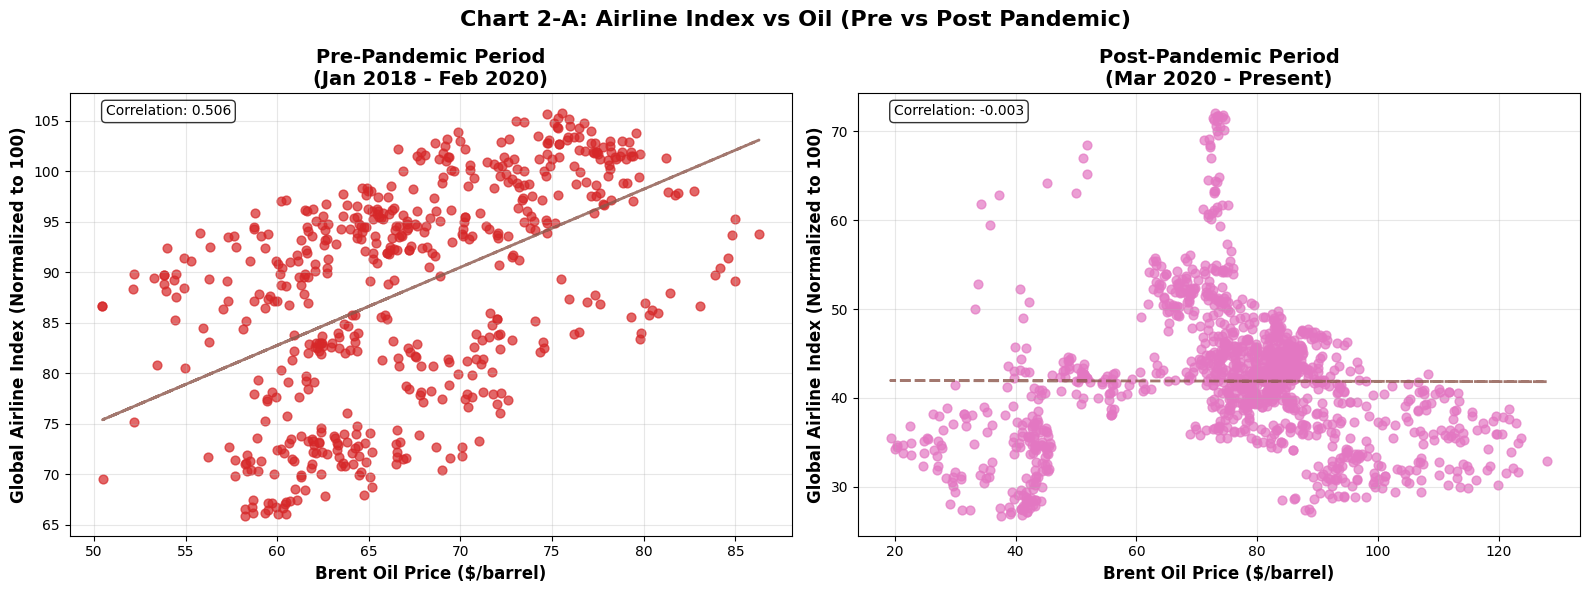


 SECTION 3: GEOPOLITICAL EVENTS & SHOCKS
--------------------------------------------------


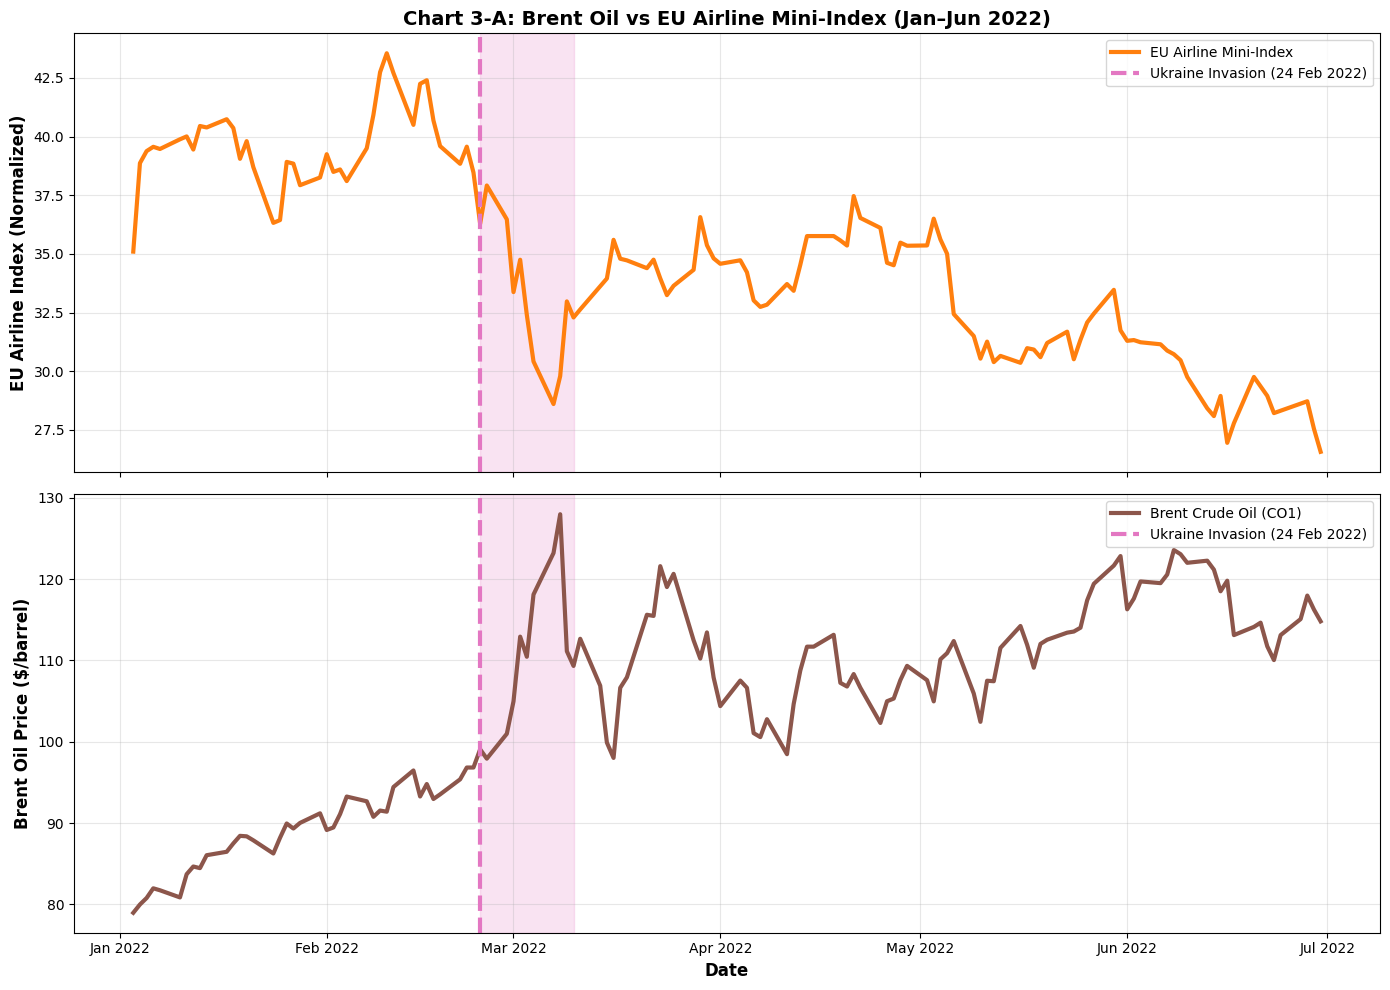

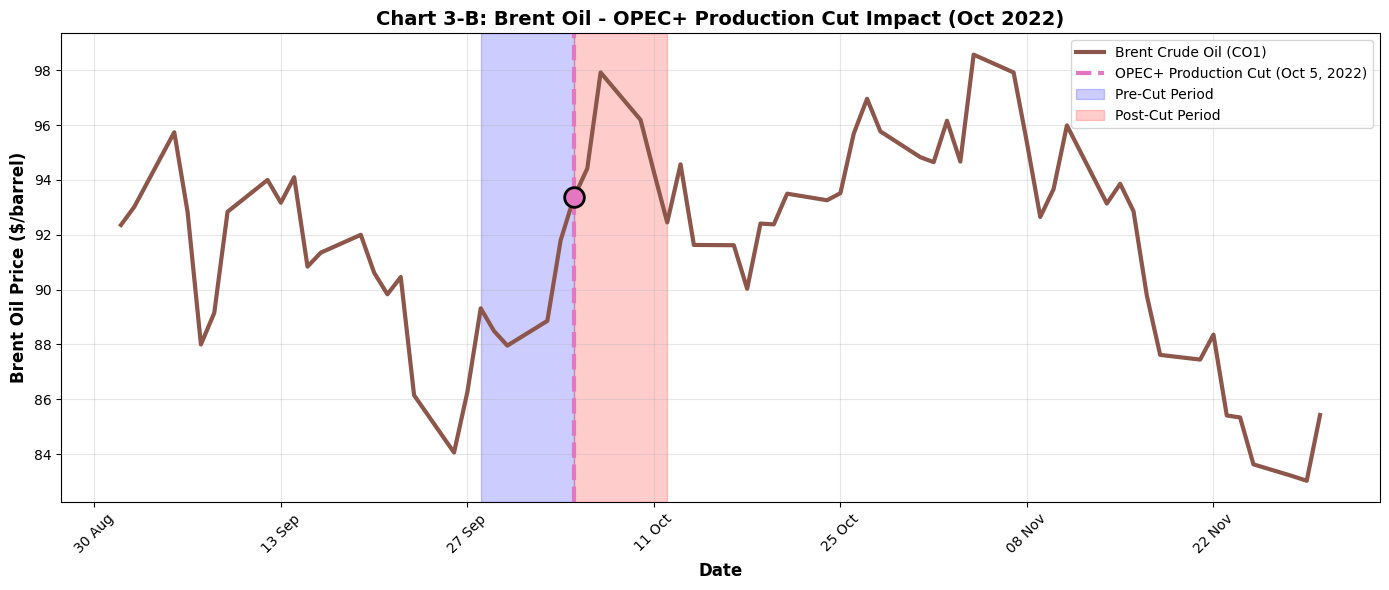


 SECTION 4: IMPACT PATHWAYS
--------------------------------------------------


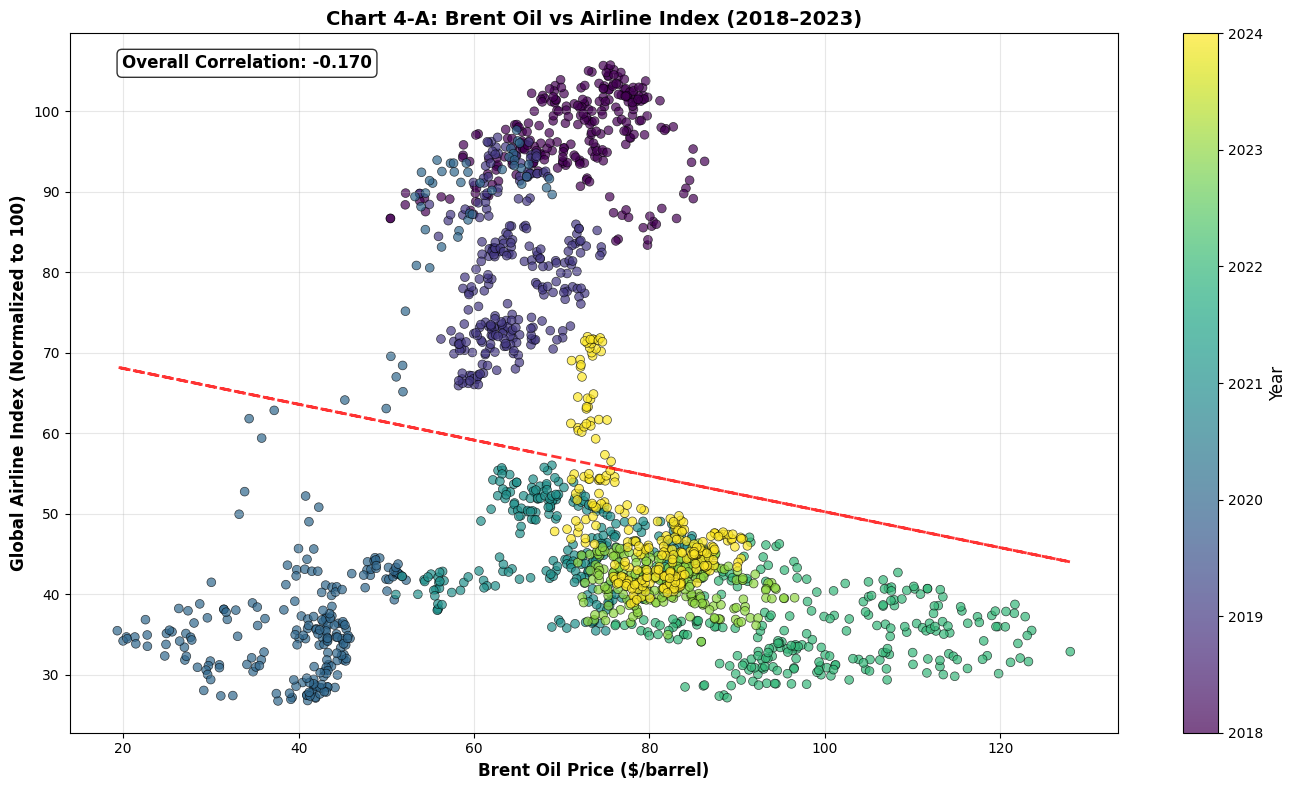

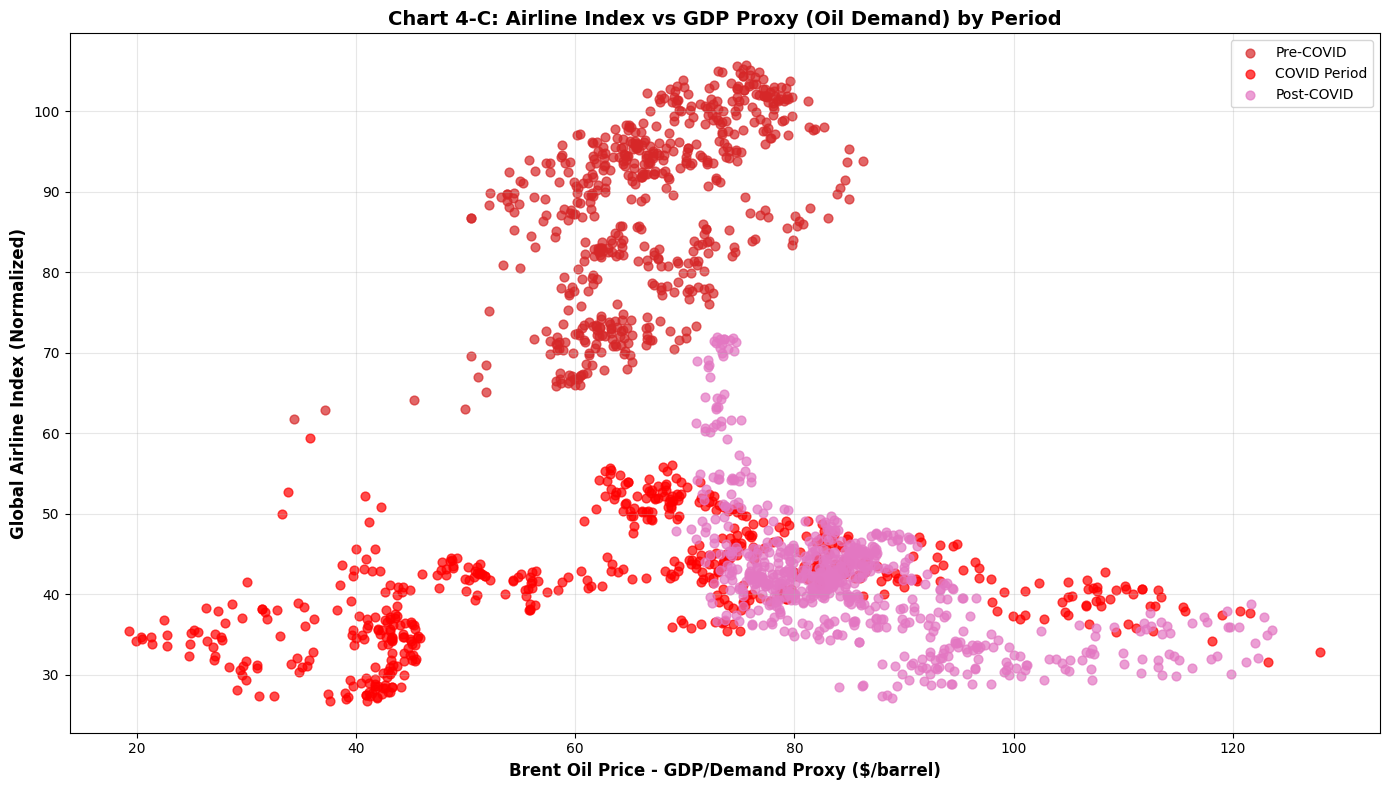

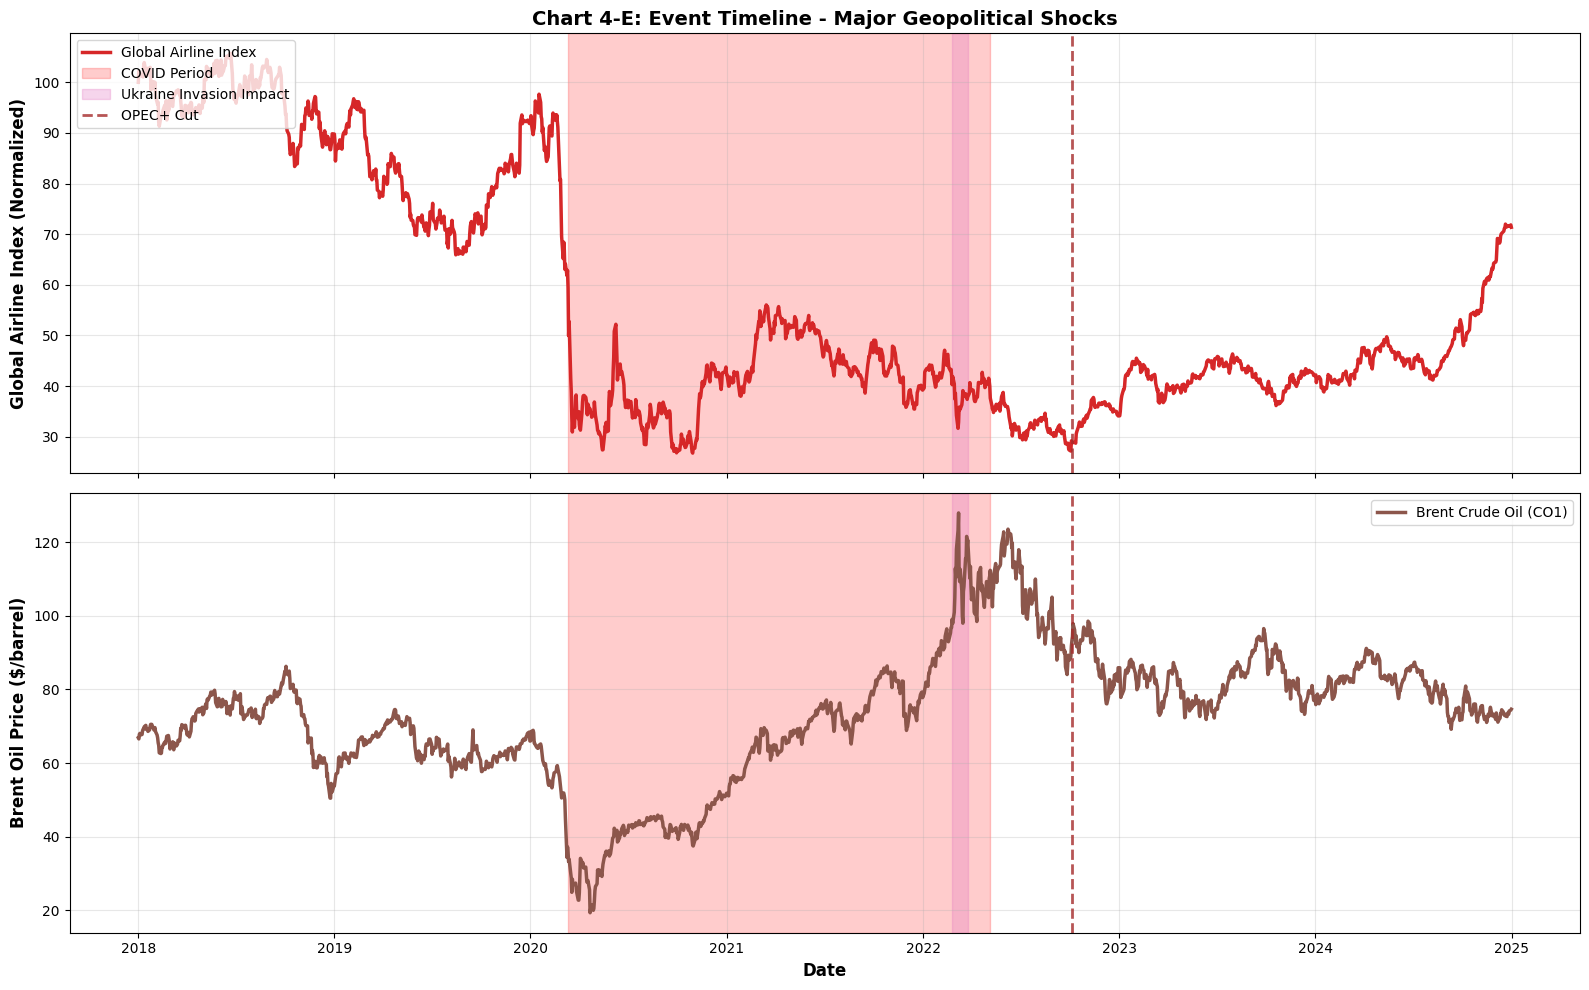


 SECTION 5: CASE STUDIES
--------------------------------------------------


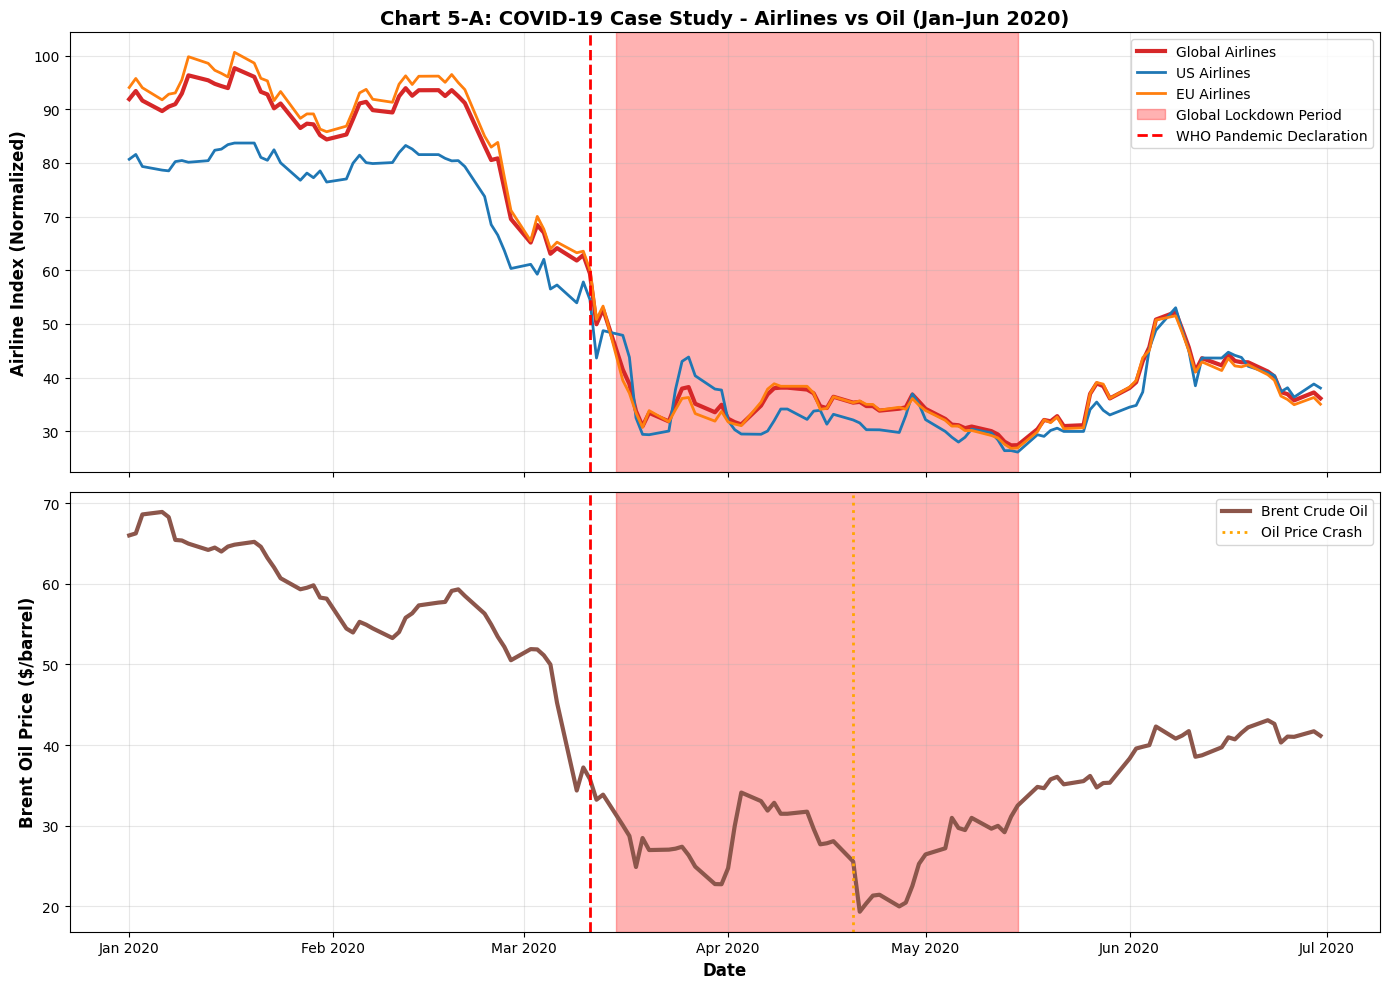

 Chart 5-B: Ukraine War Case Study
 This duplicates Chart 3-A for the case study section


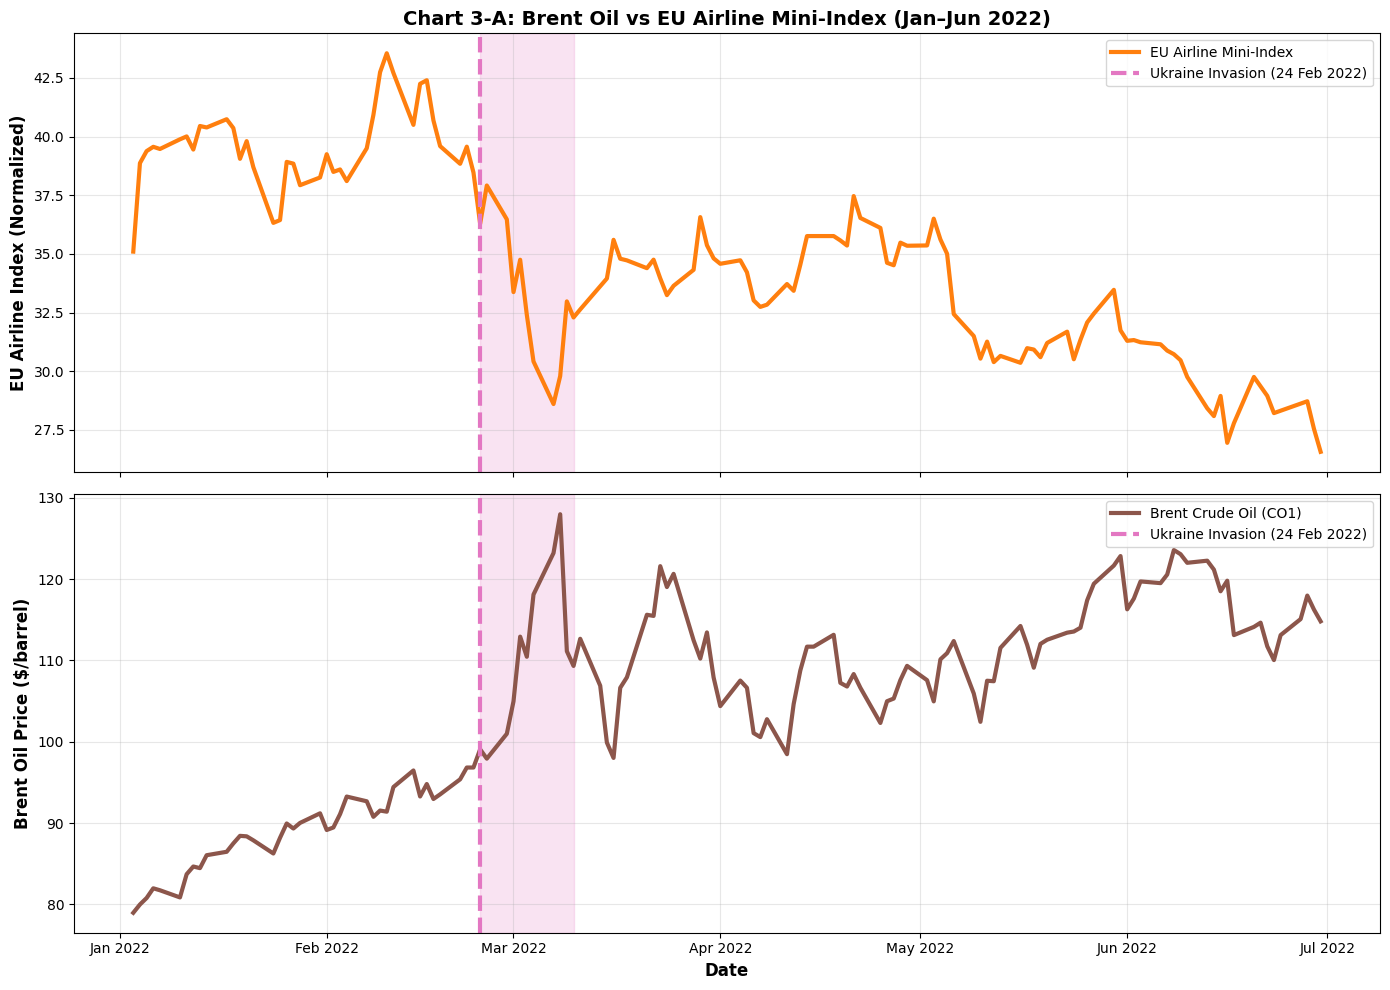


 SECTION 6: DATA-DRIVEN ANALYSIS
--------------------------------------------------


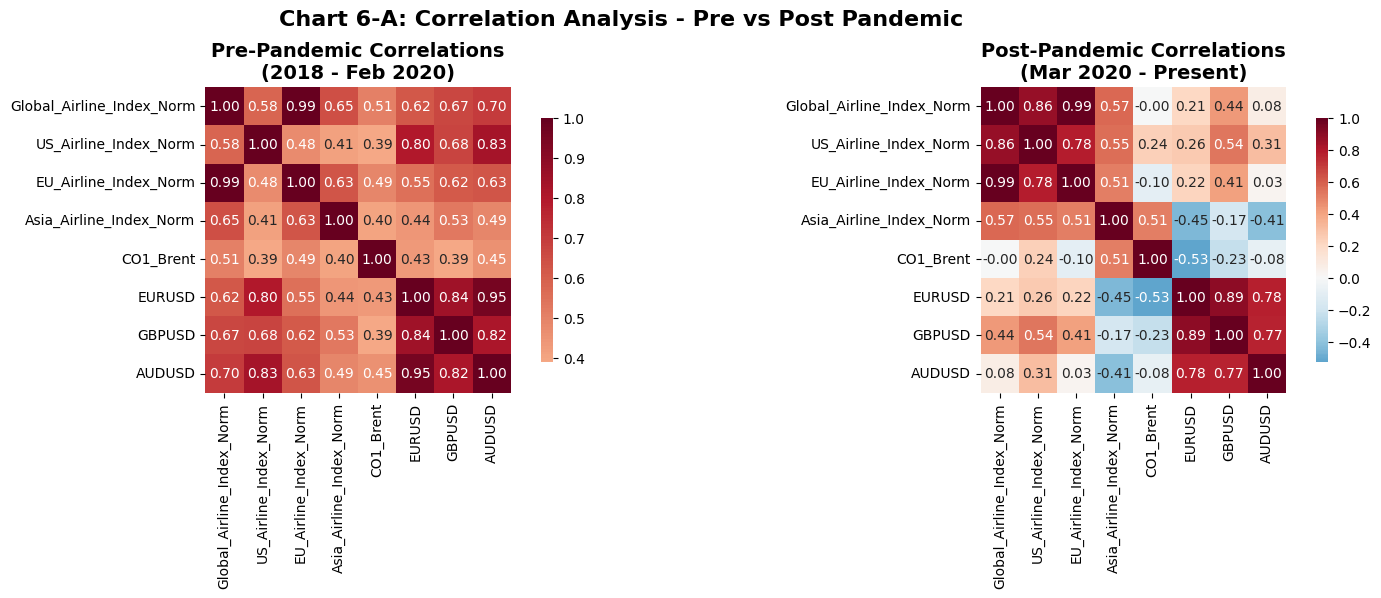

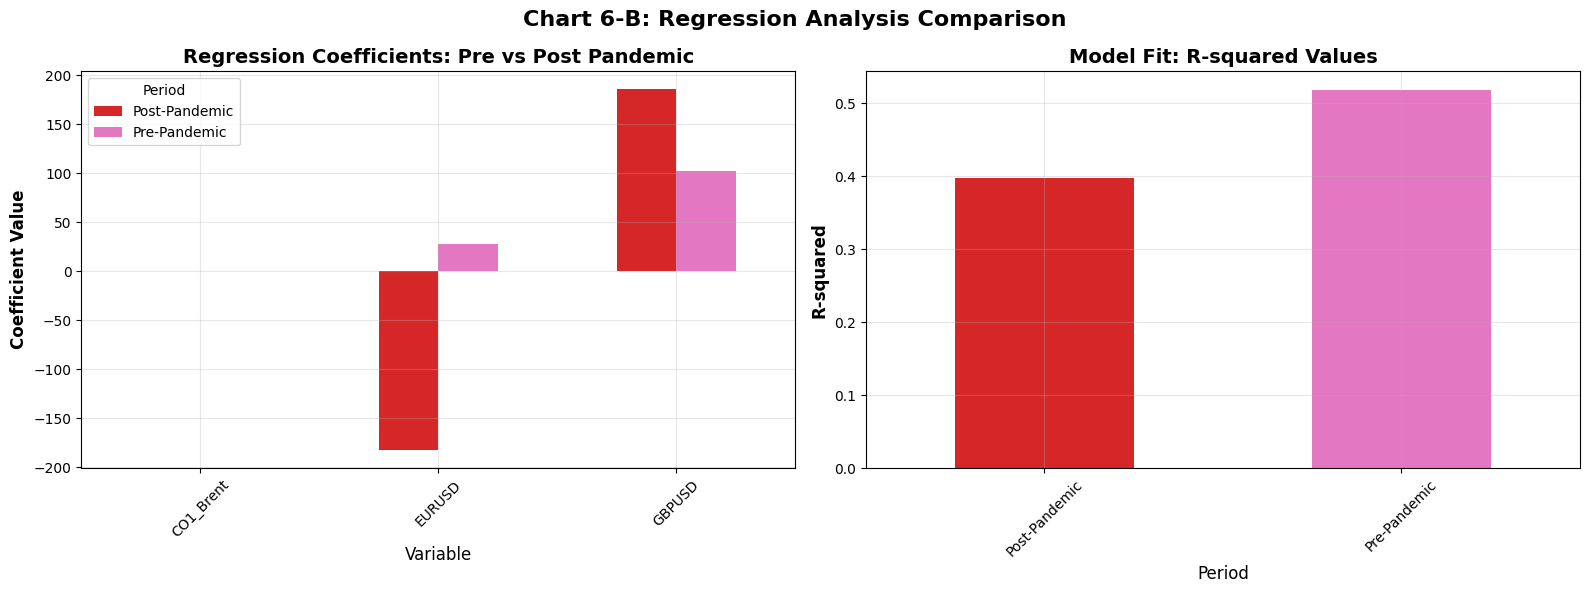


Regression Results Summary:
       Period  Variable  Coefficient  R_squared
 Pre-Pandemic CO1_Brent     0.424520   0.517721
 Pre-Pandemic    EURUSD    28.311922   0.517721
 Pre-Pandemic    GBPUSD   102.217591   0.517721
Post-Pandemic CO1_Brent    -0.141303   0.397726
Post-Pandemic    EURUSD  -182.709042   0.397726
Post-Pandemic    GBPUSD   185.805687   0.397726


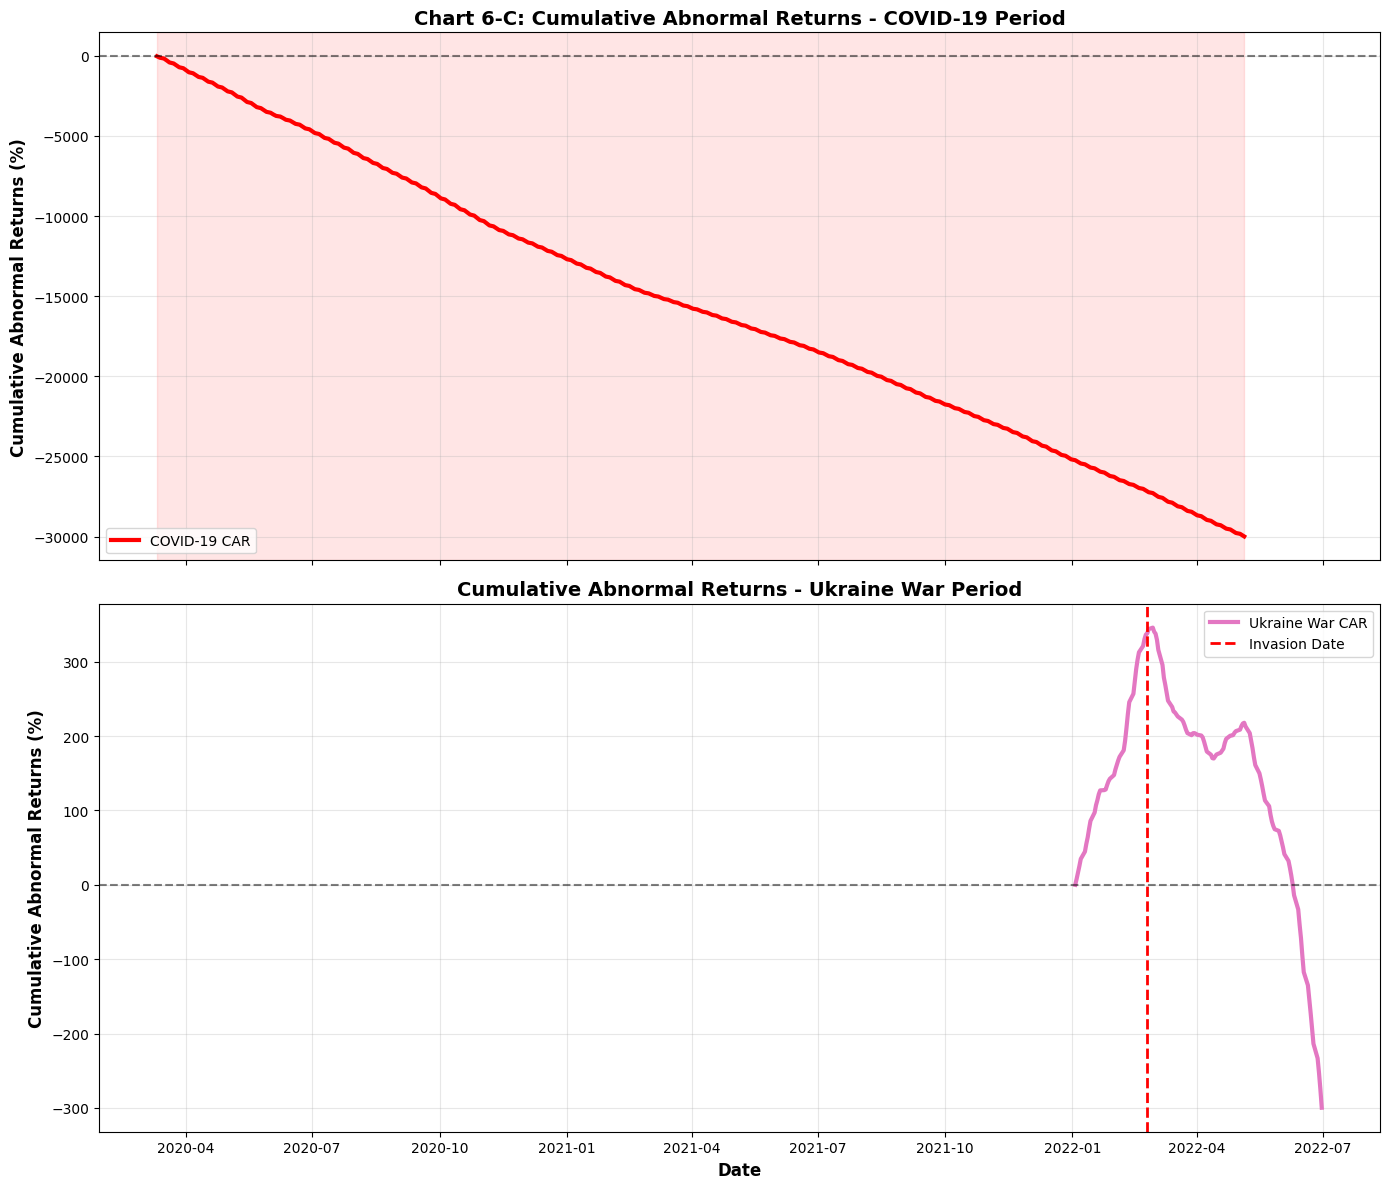

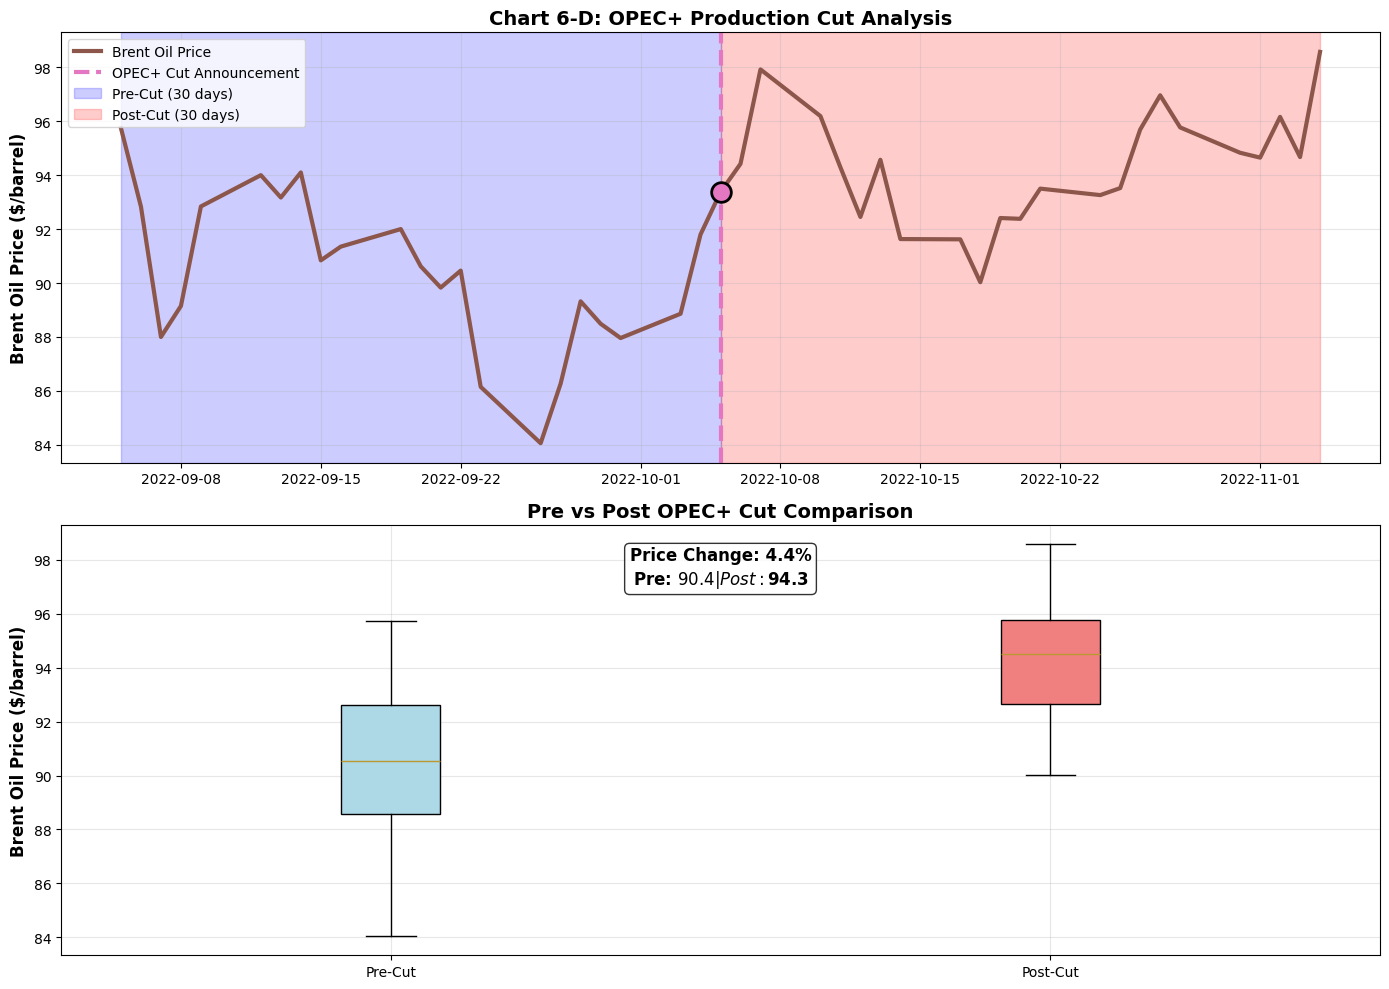

In [8]:
def chart_5a_covid_lockdown_case_study():
    """Chart 5-A: Brent vs Airline Index, Jan-Jun 2020 with lockdown window"""

    start_date = pd.to_datetime('2020-01-01')
    end_date = pd.to_datetime('2020-06-30')
    filtered_data = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

    if len(filtered_data) == 0:
        print("No data available for Jan-Jun 2020 period")
        return

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    # Airline indices
    ax1.plot(filtered_data['Date'], filtered_data['Global_Airline_Index_Norm'],
             color=colors['Global_Airlines'], linewidth=3, label='Global Airlines')
    ax1.plot(filtered_data['Date'], filtered_data['US_Airline_Index_Norm'],
             color=colors['US_Airlines'], linewidth=2, label='US Airlines')
    ax1.plot(filtered_data['Date'], filtered_data['EU_Airline_Index_Norm'],
             color=colors['EU_Airlines'], linewidth=2, label='EU Airlines')

    # Lockdown shaded window (March-May 2020)
    lockdown_start = pd.to_datetime('2020-03-15')
    lockdown_end = pd.to_datetime('2020-05-15')
    ax1.axvspan(lockdown_start, lockdown_end, alpha=0.3, color='red',
                label='Global Lockdown Period')
    ax1.axvline(x=covid_start, color='red', linestyle='--', linewidth=2,
                label='WHO Pandemic Declaration')

    ax1.set_ylabel('Airline Index (Normalized)', fontweight='bold')
    ax1.set_title('Chart 5-A: COVID-19 Case Study - Airlines vs Oil (Jan–Jun 2020)',
                  fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Brent Oil
    ax2.plot(filtered_data['Date'], filtered_data['CO1_Brent'],
             color=colors['Oil'], linewidth=3, label='Brent Crude Oil')
    ax2.axvspan(lockdown_start, lockdown_end, alpha=0.3, color='red')
    ax2.axvline(x=covid_start, color='red', linestyle='--', linewidth=2)

    # Mark oil price crash
    oil_crash_date = pd.to_datetime('2020-04-20')  # Oil futures went negative
    ax2.axvline(x=oil_crash_date, color='orange', linestyle=':', linewidth=2,
                label='Oil Price Crash')

    ax2.set_xlabel('Date', fontweight='bold')
    ax2.set_ylabel('Brent Oil Price ($/barrel)', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # Format x-axis
    ax2.xaxis.set_major_locator(mdates.MonthLocator())
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    plt.tight_layout()
    plt.show()

def chart_5b_ukraine_case_study():
    """Chart 5-B: Brent vs EU Airlines, Jan-Jun 2022 (duplicate of 3-A for case study section)"""
    print(" Chart 5-B: Ukraine War Case Study")
    print(" This duplicates Chart 3-A for the case study section")
    chart_3a_brent_vs_eu_ukraine_war()

# =============================================================================
# SECTION 6: DATA-DRIVEN ANALYSIS
# =============================================================================

def chart_6a_correlation_heatmaps():
    """Chart 6-A: Correlation heatmaps pre vs post pandemic"""

    # Prepare data for correlation analysis
    correlation_vars = ['Global_Airline_Index_Norm', 'US_Airline_Index_Norm',
                       'EU_Airline_Index_Norm', 'Asia_Airline_Index_Norm',
                       'CO1_Brent', 'EURUSD', 'GBPUSD', 'AUDUSD']

    # Split data
    pre_pandemic_data = df[df['Date'] < pandemic_start][correlation_vars].copy()
    post_pandemic_data = df[df['Date'] >= pandemic_start][correlation_vars].copy()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Pre-pandemic correlations
    if len(pre_pandemic_data) > 10:
        corr_pre = pre_pandemic_data.corr()
        sns.heatmap(corr_pre, annot=True, cmap='RdBu_r', center=0,
                   square=True, fmt='.2f', ax=ax1, cbar_kws={"shrink": .8})
        ax1.set_title('Pre-Pandemic Correlations\n(2018 - Feb 2020)', fontweight='bold')

    # Post-pandemic correlations
    if len(post_pandemic_data) > 10:
        corr_post = post_pandemic_data.corr()
        sns.heatmap(corr_post, annot=True, cmap='RdBu_r', center=0,
                   square=True, fmt='.2f', ax=ax2, cbar_kws={"shrink": .8})
        ax2.set_title('Post-Pandemic Correlations\n(Mar 2020 - Present)', fontweight='bold')

    plt.suptitle('Chart 6-A: Correlation Analysis - Pre vs Post Pandemic',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def chart_6b_regression_analysis():
    """Chart 6-B: Regression coefficient comparison"""

    # Perform regression analysis
    from sklearn.linear_model import LinearRegression

    # Prepare data
    features = ['CO1_Brent', 'EURUSD', 'GBPUSD']
    target = 'Global_Airline_Index_Norm'

    # Pre-pandemic regression
    pre_data = df[df['Date'] < pandemic_start][features + [target]].dropna()
    post_data = df[df['Date'] >= pandemic_start][features + [target]].dropna()

    results = []

    if len(pre_data) > 10 and len(post_data) > 10:
        for period, data in [('Pre-Pandemic', pre_data), ('Post-Pandemic', post_data)]:
            X = data[features]
            y = data[target]

            model = LinearRegression()
            model.fit(X, y)

            for i, feature in enumerate(features):
                results.append({
                    'Period': period,
                    'Variable': feature,
                    'Coefficient': model.coef_[i],
                    'R_squared': model.score(X, y)
                })

    # Create comparison table
    if results:
        results_df = pd.DataFrame(results)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Coefficient comparison
        pivot_coef = results_df.pivot(index='Variable', columns='Period', values='Coefficient')
        pivot_coef.plot(kind='bar', ax=ax1, color=[colors['Global_Airlines'], colors['Events']])
        ax1.set_title('Regression Coefficients: Pre vs Post Pandemic', fontweight='bold')
        ax1.set_ylabel('Coefficient Value', fontweight='bold')
        ax1.tick_params(axis='x', rotation=45)
        ax1.grid(True, alpha=0.3)

        # R-squared comparison
        r_squared_data = results_df.groupby('Period')['R_squared'].first()
        r_squared_data.plot(kind='bar', ax=ax2, color=[colors['Global_Airlines'], colors['Events']])
        ax2.set_title('Model Fit: R-squared Values', fontweight='bold')
        ax2.set_ylabel('R-squared', fontweight='bold')
        ax2.tick_params(axis='x', rotation=45)
        ax2.grid(True, alpha=0.3)

        plt.suptitle('Chart 6-B: Regression Analysis Comparison', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Print numerical results
        print("\nRegression Results Summary:")
        print(results_df.to_string(index=False))

def chart_6c_cumulative_abnormal_returns():
    """Chart 6-C: Cumulative Abnormal Returns during COVID and Ukraine war"""

    # Calculate abnormal returns (simplified approach)
    # Using pre-pandemic average as baseline

    baseline_period = df[df['Date'] < pandemic_start]['Global_Airline_Index_Norm'].mean()
    df['Abnormal_Returns'] = ((df['Global_Airline_Index_Norm'] / baseline_period) - 1) * 100

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

    # COVID period CARs
    covid_data = df[(df['Date'] >= covid_start) & (df['Date'] <= covid_end)].copy()
    if len(covid_data) > 0:
        covid_data['CAR'] = covid_data['Abnormal_Returns'].cumsum()
        ax1.plot(covid_data['Date'], covid_data['CAR'],
                color='red', linewidth=3, label='COVID-19 CAR')
        ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax1.axvspan(covid_start, covid_end, alpha=0.1, color='red')
        ax1.set_ylabel('Cumulative Abnormal Returns (%)', fontweight='bold')
        ax1.set_title('Chart 6-C: Cumulative Abnormal Returns - COVID-19 Period', fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.legend()

    # Ukraine war period CARs
    ukraine_start = pd.to_datetime('2022-01-01')
    ukraine_end = pd.to_datetime('2022-06-30')
    ukraine_data = df[(df['Date'] >= ukraine_start) & (df['Date'] <= ukraine_end)].copy()

    if len(ukraine_data) > 0:
        # Reset CAR calculation for Ukraine period
        ukraine_baseline = ukraine_data['Global_Airline_Index_Norm'].iloc[0]
        ukraine_data['Ukraine_Abnormal'] = ((ukraine_data['Global_Airline_Index_Norm'] / ukraine_baseline) - 1) * 100
        ukraine_data['Ukraine_CAR'] = ukraine_data['Ukraine_Abnormal'].cumsum()

        ax2.plot(ukraine_data['Date'], ukraine_data['Ukraine_CAR'],
                color=colors['Events'], linewidth=3, label='Ukraine War CAR')
        ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax2.axvline(x=ukraine_invasion, color='red', linestyle='--', linewidth=2,
                   label='Invasion Date')
        ax2.set_xlabel('Date', fontweight='bold')
        ax2.set_ylabel('Cumulative Abnormal Returns (%)', fontweight='bold')
        ax2.set_title('Cumulative Abnormal Returns - Ukraine War Period', fontweight='bold')
        ax2.grid(True, alpha=0.3)
        ax2.legend()

    plt.tight_layout()
    plt.show()

def chart_6d_opec_cut_analysis():
    """Chart 6-D: Brent prices pre/post OPEC+ cut"""

    pre_start = opec_cut - pd.Timedelta(days=30)
    post_end = opec_cut + pd.Timedelta(days=30)

    analysis_data = df[(df['Date'] >= pre_start) & (df['Date'] <= post_end)].copy()

    if len(analysis_data) == 0:
        print("No data available for OPEC+ analysis period")
        return

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # Time series with event marker
    ax1.plot(analysis_data['Date'], analysis_data['CO1_Brent'],
             color=colors['Oil'], linewidth=3, label='Brent Oil Price')
    ax1.axvline(x=opec_cut, color=colors['Events'], linestyle='--', linewidth=3,
                label='OPEC+ Cut Announcement')
    ax1.axvspan(pre_start, opec_cut, alpha=0.2, color='blue', label='Pre-Cut (30 days)')
    ax1.axvspan(opec_cut, post_end, alpha=0.2, color='red', label='Post-Cut (30 days)')

    # Mark the actual event
    event_data = analysis_data[analysis_data['Date'].dt.date == opec_cut.date()]
    if not event_data.empty:
        ax1.scatter([opec_cut], [event_data['CO1_Brent'].iloc[0]],
                   color=colors['Events'], s=200, marker='o', zorder=5,
                   edgecolors='black', linewidths=2)

    ax1.set_ylabel('Brent Oil Price ($/barrel)', fontweight='bold')
    ax1.set_title('Chart 6-D: OPEC+ Production Cut Analysis', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Pre vs Post comparison (box plot)
    pre_cut_data = analysis_data[analysis_data['Date'] < opec_cut]['CO1_Brent'].dropna()
    post_cut_data = analysis_data[analysis_data['Date'] > opec_cut]['CO1_Brent'].dropna()

    box_data = []
    labels = []
    if len(pre_cut_data) > 0:
        box_data.append(pre_cut_data)
        labels.append('Pre-Cut')
    if len(post_cut_data) > 0:
        box_data.append(post_cut_data)
        labels.append('Post-Cut')

    if len(box_data) == 2:
        bp = ax2.boxplot(box_data, labels=labels, patch_artist=True)
        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][1].set_facecolor('lightcoral')

        # Add statistics
        pre_mean = pre_cut_data.mean()
        post_mean = post_cut_data.mean()
        change = ((post_mean - pre_mean) / pre_mean) * 100

        ax2.text(0.5, 0.95, f'Price Change: {change:.1f}%\nPre: ${pre_mean:.1f} | Post: ${post_mean:.1f}',
                transform=ax2.transAxes, ha='center', va='top', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    ax2.set_ylabel('Brent Oil Price ($/barrel)', fontweight='bold')
    ax2.set_title('Pre vs Post OPEC+ Cut Comparison', fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def generate_all_charts():

    print("\n SECTION 2: KEY MACROECONOMIC VARIABLES")
    print("-" * 50)
    chart_2a_airline_vs_oil_pre_post_pandemic()

    print("\n SECTION 3: GEOPOLITICAL EVENTS & SHOCKS")
    print("-" * 50)
    chart_3a_brent_vs_eu_ukraine_war()
    chart_3b_brent_opec_cut()

    print("\n SECTION 4: IMPACT PATHWAYS")
    print("-" * 50)
    chart_4a_brent_vs_airline_2018_2023()
    chart_4c_airline_vs_gdp_proxy()
    chart_4e_event_timeline()

    print("\n SECTION 5: CASE STUDIES")
    print("-" * 50)
    chart_5a_covid_lockdown_case_study()
    chart_5b_ukraine_case_study()

    print("\n SECTION 6: DATA-DRIVEN ANALYSIS")
    print("-" * 50)
    chart_6a_correlation_heatmaps()
    chart_6b_regression_analysis()
    chart_6c_cumulative_abnormal_returns()
    chart_6d_opec_cut_analysis()



generate_all_charts()